# Motoneurons

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display, HTML


# exit() gracefully
class StopExecution(Exception):
    def _render_traceback_(self):
        display(HTML(f"<span style='color: #3989cf;'>Early exit</span>"))


def exit():
    raise StopExecution


np.set_printoptions(suppress=True)
%matplotlib inline
%load_ext autoreload
%autoreload 2

Storage configuration

In [2]:
from machinable import get

if "STORAGE" not in os.environ:
    raise RuntimeError("Please set a storage directory")

get("machinable.index", os.environ["STORAGE"]).__enter__()

machinable.index [d2eff8]

## Create the network

In [3]:
from miv_simulator.utils import from_yaml

with get("interface.execution.slurm", {"partition": "small"}):
    synapses_config = from_yaml("simulation/config/synapses.yml")

    h5_types = get(
        "miv_simulator.interface.h5_types",
        [
            {
                "cell_distributions": {
                    "STIM": {"SO": 0, "SP": 64, "SR": 0, "SLM": 0},
                    "PYR": {"SO": 0, "SP": 223, "SR": 0, "SLM": 0},
                    "PVBC": {"SO": 35, "SP": 50, "SR": 8, "SLM": 0},
                    "OLM": {"SO": 21, "SP": 0, "SR": 0, "SLM": 0},
                },
                "projections": {
                    post: list(pre.keys()) for post, pre in synapses_config.items()
                },
            },
        ],
    ).launch()

    network = get(
        "miv_simulator.interface.network_architecture",
        {
            "filepath": h5_types.output_filepath,
            "cell_distributions": h5_types.config.cell_distributions,
            "layer_extents": {
                "SO": [[0.0, 0.0, 0.0], [200.0, 200.0, 5.0]],
                "SP": [[0.0, 0.0, 5.0], [200.0, 200.0, 50.0]],
                "SR": [[0.0, 0.0, 50.0], [200.0, 200.0, 100.0]],
                "SLM": [[0.0, 0.0, 100.0], [200.0, 200.0, 150.0]],
            },
        },
        uses=h5_types,
    ).launch()

    measure_distances = network.measure_distances().launch()

    synapse_forest = {
        population: network.generate_synapse_forest(
            {
                "population": population,
                "morphology": f"./simulation/morphology/{population}.swc",
            },
            uses=measure_distances,
        ).launch()
        for population in ["PYR", "PVBC", "OLM"]
    }

    synapses = {
        population: network.distribute_synapses(
            {
                "forest_filepath": synapse_forest[population].output_filepath,
                "cell_types": "from_file('simulation/config/cell_types.yml')",
                "population": population,
                "distribution": "poisson",
                "mechanisms_path": "./simulation/mechanisms",
                "template_path": "./simulation/templates",
                "io_size": 1,
                "write_size": 0,
            },
            uses=list(synapse_forest.values()),
        ).launch()
        for population in ["PYR", "PVBC", "OLM"]
    }

    connections = {
        population: network.generate_connections(
            {
                "synapses": synapses_config,
                "forest_filepath": synapses[population].output_filepath,
                "axon_extents": {
                    "STIM": {"default": {"width": [200, 200], "offset": [0, 0]}},
                    "PYR": {"default": {"width": [200, 200], "offset": [0, 0]}},
                    "PVBC": {"default": {"width": [200, 200], "offset": [0, 0]}},
                    "OLM": {"default": {"width": [200, 200], "offset": [0, 0]}},
                },
                "template_path": "./simulation/templates",
                "io_size": 1,
                "cache_size": 20,
                "write_size": 100,
            },
            uses=list(synapses.values()),
        ).launch()
        for population in ["PYR", "PVBC", "OLM"]
    }

    graph = get(
        "miv_simulator.interface.neuroh5_graph",
        uses=[
            network,
            *synapse_forest.values(),
            *synapses.values(),
            *connections.values(),
        ],
    ).launch()

graph.files()

numprocs=1
Submitting 13 jobs (13 total). Proceed? [Y/n]: no


{'cells': '/scratch1/08818/fg14/storage/065417e59c127faa800039562f9b51a1/cells.h5',
 'connections': '/scratch1/08818/fg14/storage/065417e59c127faa800039562f9b51a1/connections.h5'}

## Separation property experiment

Following Maass et al. 2002 (Figure 2).

In [4]:
from collections import defaultdict
from miv_simulator import coding
from machinable import Component


def generate_poisson_spike_train(rate_hz, duration_ms) -> coding.SpikeTimes:
    duration_s = duration_ms / 1000.0
    ISIs = np.random.exponential(1.0 / rate_hz, int(rate_hz * duration_s * 1.5))
    spike_times = np.cumsum(ISIs)
    spike_times = spike_times[spike_times < duration_s]
    return coding.cast_spike_times(spike_times * 1000)


def gaussian_conv(spike_times, duration, tau=5, dt=0.1):
    t = np.arange(0, duration + dt, dt)
    spike_function = np.zeros_like(t)
    for spike in spike_times:
        spike_function[int(spike / dt)] = 1
    w = 3
    x = np.arange(-w * tau, w * tau + dt, dt)
    kernel = np.exp(-((x / tau) ** 2))
    return np.convolve(spike_function, kernel, mode="same")


def spike_train_distance(u_times, v_times, duration, tau=5):
    """d(u, v) in Maass+2002"""
    u_continuous = gaussian_conv(u_times, duration, tau)
    v_continuous = gaussian_conv(v_times, duration, tau)
    distance = np.linalg.norm(u_continuous - v_continuous)
    return distance / duration


class SpikeTrainPairs(Component):
    class Config:
        N: int = 200
        distance: float = 0.1
        splits: int = 10
        duration: float = 500

    def __call__(self):
        distances = [self.config.distance]

        g = lambda r: generate_poisson_spike_train(r, self.config.duration)
        d = lambda a, b: spike_train_distance(a, b, duration=self.config.duration)

        # figure out frequencies for which distances are likely
        m = {t: (0, None) for t in distances}
        for ff in range(
            1, 100, 1
        ):  # 5Hz spontanous, so around 10Hz might be reasonable
            f = ff * self.config.splits
            dd = np.mean([d(g(f), g(f)) for _ in range(50)])
            print(f, dd)
            for k, v in m.items():
                if k - v[0] > dd - v[0]:
                    m[k] = (dd, f)
        print(f"Frequency-distance map: {m}")

        # plt.hist([d(g(), g()) for _ in range(200)], bins=20)
        # plt.show()

        eps = 0.01
        data = defaultdict(list)
        for target in distances:
            f = m[target][1]
            while len(data[target]) < self.config.N:
                u, v = g(f), g(f)
                dd = d(u, v)
                if np.abs(dd - target) < eps:
                    data[target].append((u, v))

        self.save_file("data.p", data[self.config.distance])

    def data(self):
        return self.load_file("data.p", None)


with get("interface.execution.slurm"):
    spike_trains = {
        distance: get(SpikeTrainPairs, {"distance": distance}).launch()
        for distance in [0.1, 0.2, 0.4]
    }

For distance 0.0, found 10/10 cached experiments
For distance 0.1, found 10/10 cached experiments


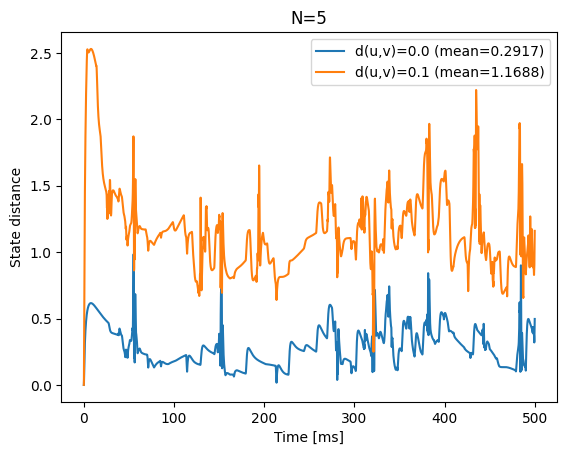

In [13]:
with get("interface.execution.slurm", {"partition": "normal", "nodes": 8, "ranks": 32}):
    fig = plt.figure()
    for distance in [
        0.0,
        0.1,
    ]:  # 0.2, 0.4]:
        total = 0
        finished = 0
        data = spike_trains[
            distance if distance != 0 else list(spike_trains.keys())[0]
        ].data()
        x = []
        y = []
        for trial in range(5):  # spike_trains[distance].config.N
            experiment = {}
            for u_or_v in range(2):
                stimulus = data[trial][u_or_v].tolist()
                context = {}
                if distance == 0.0:
                    # use the same stimulus u but with different initialization context
                    stimulus = data[trial][0].tolist()
                    context = {"state": u_or_v}
                with get("machinable.scope", {"trial": trial, **context}):
                    experiment["u" if u_or_v == 0 else "v"] = e = get(
                        "interface.experiment.rc",
                        [
                            graph.files(),
                            {
                                "t_end": 500,
                                "cell_types": "from_file('simulation/config/cell_types.yml')",
                                "synapses": "from_file('simulation/config/synapses.yml')",
                                "stimulus": stimulus,
                            },
                        ],
                    ).launch()
                    total += 1
                    if e.cached():
                        finished += 1
            u = experiment["u"].readout()
            v = experiment["v"].readout()
            if u is None or v is None:
                continue
            state_distance = np.abs(u[:, 1] - v[:, 1])
            x = u[:, 0]
            y.append(state_distance)
        print(f"For distance {distance}, found {finished}/{total} cached experiments")
        if finished != total:
            continue
        state_distances = np.array(y)
        state_distance_avg = y = np.mean(state_distances, axis=0)
        state_distance_std = error = np.std(state_distances, axis=0)
        reduced = np.mean(state_distance_avg)
        plt.plot(x, y, label=f"d(u,v)={distance} (mean={round(reduced, 4)})")
        # plt.fill_between(x, y - error, y + error)

    plt.legend(loc="upper right")
    plt.title(f"N={trial+1}")
    plt.xlabel("Time [ms]")
    plt.ylabel("State distance")
    plt.show()